In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading Dataset
data = pd.read_csv("weather_condition_classification_logreg.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         1000 non-null   int64  
 1   Observation_Date  1000 non-null   str    
 2   Temperature_C     1000 non-null   float64
 3   Humidity_pct      1000 non-null   float64
 4   Pressure_hPa      1000 non-null   float64
 5   WindSpeed_kmh     1000 non-null   float64
 6   Visibility_km     1000 non-null   float64
 7   Precipitation_mm  1000 non-null   float64
 8   Elevation_m       1000 non-null   float64
 9   CloudCover_pct    1000 non-null   float64
 10  Region            1000 non-null   str    
 11  Season            1000 non-null   str    
 12  TimeOfDay         1000 non-null   str    
 13  Station_Type      1000 non-null   str    
 14  Cold_Front        1000 non-null   bool   
 15  Storm_Alert       1000 non-null   bool   
 16  Target_Column     1000 non-null   int64  
dtypes: bool

In [3]:
data.drop(["Record_ID","Observation_Date"], axis=1, inplace=True)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temperature_C     1000 non-null   float64
 1   Humidity_pct      1000 non-null   float64
 2   Pressure_hPa      1000 non-null   float64
 3   WindSpeed_kmh     1000 non-null   float64
 4   Visibility_km     1000 non-null   float64
 5   Precipitation_mm  1000 non-null   float64
 6   Elevation_m       1000 non-null   float64
 7   CloudCover_pct    1000 non-null   float64
 8   Region            1000 non-null   str    
 9   Season            1000 non-null   str    
 10  TimeOfDay         1000 non-null   str    
 11  Station_Type      1000 non-null   str    
 12  Cold_Front        1000 non-null   bool   
 13  Storm_Alert       1000 non-null   bool   
 14  Target_Column     1000 non-null   int64  
dtypes: bool(2), float64(8), int64(1), str(4)
memory usage: 103.6 KB


In [4]:
data.dtypes

Temperature_C       float64
Humidity_pct        float64
Pressure_hPa        float64
WindSpeed_kmh       float64
Visibility_km       float64
Precipitation_mm    float64
Elevation_m         float64
CloudCover_pct      float64
Region                  str
Season                  str
TimeOfDay               str
Station_Type            str
Cold_Front             bool
Storm_Alert            bool
Target_Column         int64
dtype: object

In [5]:
data["Cold_Front"] = data["Cold_Front"].astype(str)
data["Storm_Alert"] = data["Storm_Alert"].astype(str)
data.dtypes

Temperature_C       float64
Humidity_pct        float64
Pressure_hPa        float64
WindSpeed_kmh       float64
Visibility_km       float64
Precipitation_mm    float64
Elevation_m         float64
CloudCover_pct      float64
Region                  str
Season                  str
TimeOfDay               str
Station_Type            str
Cold_Front              str
Storm_Alert             str
Target_Column         int64
dtype: object

In [6]:
print(data.select_dtypes(include=[np.number]).columns)
print("\n\n")
print(data.select_dtypes(include=[pd.StringDtype]).columns)

Index(['Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'WindSpeed_kmh',
       'Visibility_km', 'Precipitation_mm', 'Elevation_m', 'CloudCover_pct',
       'Target_Column'],
      dtype='str')



Index(['Region', 'Season', 'TimeOfDay', 'Station_Type', 'Cold_Front',
       'Storm_Alert'],
      dtype='str')


C:\Users\omkar\AppData\Local\Temp\ipykernel_6240\2633364717.py:3: UserWarning: Instantiating StringDtype without any arguments.Pass a StringDtype instance to silence this warning.
  print(data.select_dtypes(include=[pd.StringDtype]).columns)


In [7]:
numeric_features = ['Temperature_C', 'Humidity_pct', 'Pressure_hPa', 'WindSpeed_kmh',
       'Visibility_km', 'Precipitation_mm', 'Elevation_m', 'CloudCover_pct']
nominal_features = ['Region', 'Season', 'TimeOfDay', 'Station_Type', 'Cold_Front','Storm_Alert']
# ordinal_features = ['Student_Motivation_Level']

**Data Cleaning and Preprocessing**

In [14]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')

# SimpleImputer(strategy='median')
# SimpleImputer(strategy='most_frequent')
# SimpleImputer(strategy='constant', fill_value=0)


# cat_imputer = SimpleImputer(strategy='most_frequent')
# cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

In [12]:
# from sklearn.impute import SimpleImputer

# num_imputer = SimpleImputer(strategy='mean')

# X_num = pd.DataFrame(
#     num_imputer.fit_transform(X_num),
#     columns=numerical_features
# )


# cat_imputer = SimpleImputer(strategy='most_frequent')

# X_cat = pd.DataFrame(
#     cat_imputer.fit_transform(X_cat),
#     columns=nominal_features
# )

**Data Encoding**

In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_cat_encoded = encoder.fit_transform(data[nominal_features])

encoded_columns = encoder.get_feature_names_out(nominal_features)

X_cat_encoded = pd.DataFrame(
    X_cat_encoded,
    columns=encoded_columns
)

X_cat_encoded

,Region_Coastal,Region_East,Region_Mountain,Region_North,Region_South,Region_West,Season_Autumn,Season_Spring,Season_Summer,Season_Winter,...,Station_Type_Coastal,Station_Type_Rural,Station_Type_URBAN,Station_Type_Urban,Station_Type_rural,Station_Type_urban,Cold_Front_False,Cold_Front_True,Storm_Alert_False,Storm_Alert_True
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
997,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
998,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


**Feature Scaling**

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num_scaled = pd.DataFrame(
    scaler.fit_transform(data[numeric_features]),
    columns=numeric_features
)

X_num_scaled

,Temperature_C,Humidity_pct,Pressure_hPa,WindSpeed_kmh,Visibility_km,Precipitation_mm,Elevation_m,CloudCover_pct
0,-0.264172,-1.310736,0.410908,0.063966,0.212889,-1.043112,-0.203014,-0.992246
1,1.182543,-0.499029,1.921655,-0.090113,-0.445815,-0.624787,0.070887,-0.071953
2,-2.743727,1.700752,-0.937735,0.672291,0.089679,0.070400,-0.710919,0.122990
3,0.489888,0.277813,-0.460727,-0.673330,1.136971,-0.218588,-0.774609,1.159437
4,-0.265400,1.297623,1.565560,0.475984,-0.085660,0.025940,0.833013,1.438043
...,...,...,...,...,...,...,...,...
995,0.719545,0.003249,0.955681,-0.052450,0.426139,0.905029,-0.728264,-0.231968
996,-1.837381,-0.996949,2.155508,-0.574035,0.047029,-0.226671,1.441799,-1.051541
997,-1.440702,-0.587282,1.196178,0.783000,1.577686,-0.457053,0.288566,1.009981
998,-0.023462,-0.635221,0.575669,0.457722,0.056506,-0.182212,-0.564138,1.049781


In [12]:
y = data["Target_Column"]
y

0      0
1      0
2      1
3      0
4      1
      ..
995    0
996    0
997    0
998    0
999    0
Name: Target_Column, Length: 1000, dtype: int64

In [13]:
X_final = pd.concat(
    [X_num_scaled, X_cat_encoded],
    axis=1
)

X_final

,Temperature_C,Humidity_pct,Pressure_hPa,WindSpeed_kmh,Visibility_km,Precipitation_mm,Elevation_m,CloudCover_pct,Region_Coastal,Region_East,...,Station_Type_Coastal,Station_Type_Rural,Station_Type_URBAN,Station_Type_Urban,Station_Type_rural,Station_Type_urban,Cold_Front_False,Cold_Front_True,Storm_Alert_False,Storm_Alert_True
0,-0.264172,-1.310736,0.410908,0.063966,0.212889,-1.043112,-0.203014,-0.992246,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.182543,-0.499029,1.921655,-0.090113,-0.445815,-0.624787,0.070887,-0.071953,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-2.743727,1.700752,-0.937735,0.672291,0.089679,0.070400,-0.710919,0.122990,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.489888,0.277813,-0.460727,-0.673330,1.136971,-0.218588,-0.774609,1.159437,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-0.265400,1.297623,1.565560,0.475984,-0.085660,0.025940,0.833013,1.438043,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.719545,0.003249,0.955681,-0.052450,0.426139,0.905029,-0.728264,-0.231968,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
996,-1.837381,-0.996949,2.155508,-0.574035,0.047029,-0.226671,1.441799,-1.051541,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
997,-1.440702,-0.587282,1.196178,0.783000,1.577686,-0.457053,0.288566,1.009981,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
998,-0.023462,-0.635221,0.575669,0.457722,0.056506,-0.182212,-0.564138,1.049781,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


**Data Splitting**

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing data shape: X={X_test.shape}, y={y_test.shape}")

Training data shape: X=(800, 32), y=(800,)
Testing data shape: X=(200, 32), y=(200,)


**Model Training**

In [15]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [16]:
print(model.coef_)
print(model.intercept_)

[[ 1.61028966  1.92732672  0.05572754  2.93385853 -0.26911224  0.89342744
   0.52656811  0.99703307  0.51428776  0.35178146 -0.25929036  0.06895564
  -0.09008706 -0.57935081 -0.53594789 -0.57615622  0.12432177  0.99407899
   0.03783865 -0.26452252  0.25309853 -0.02011803  0.14224269  0.52035508
  -0.54546793  0.37494457 -0.42306121 -0.06271657  0.08293782 -0.07664118
  -0.28935095  0.29564759]]
[-2.50928648]


**Prediction**

In [17]:
# Predict on test data
y_pred = model.predict(X_test)

# Display first 5 predictions against actual values
results_df = pd.DataFrame({'Actual Marks': y_test, 'Predicted Marks': y_pred})

results_df

,Actual Marks,Predicted Marks
521,0,1
737,1,1
740,0,0
660,0,0
411,0,1
...,...,...
408,0,0
332,1,1
208,0,0
613,1,1


In [18]:
model.score(X_test, y_test)

0.86

**Model Evaluation**

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions
y_pred = model.predict(X_test)

# Probabilities for positive class
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("--- Logistic Regression Evaluation Metrics ---")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

--- Logistic Regression Evaluation Metrics ---
Accuracy:  0.8600 (86.00%)
Precision: 0.8254
Recall:    0.7536
F1 Score:  0.7879
ROC-AUC:   0.9295


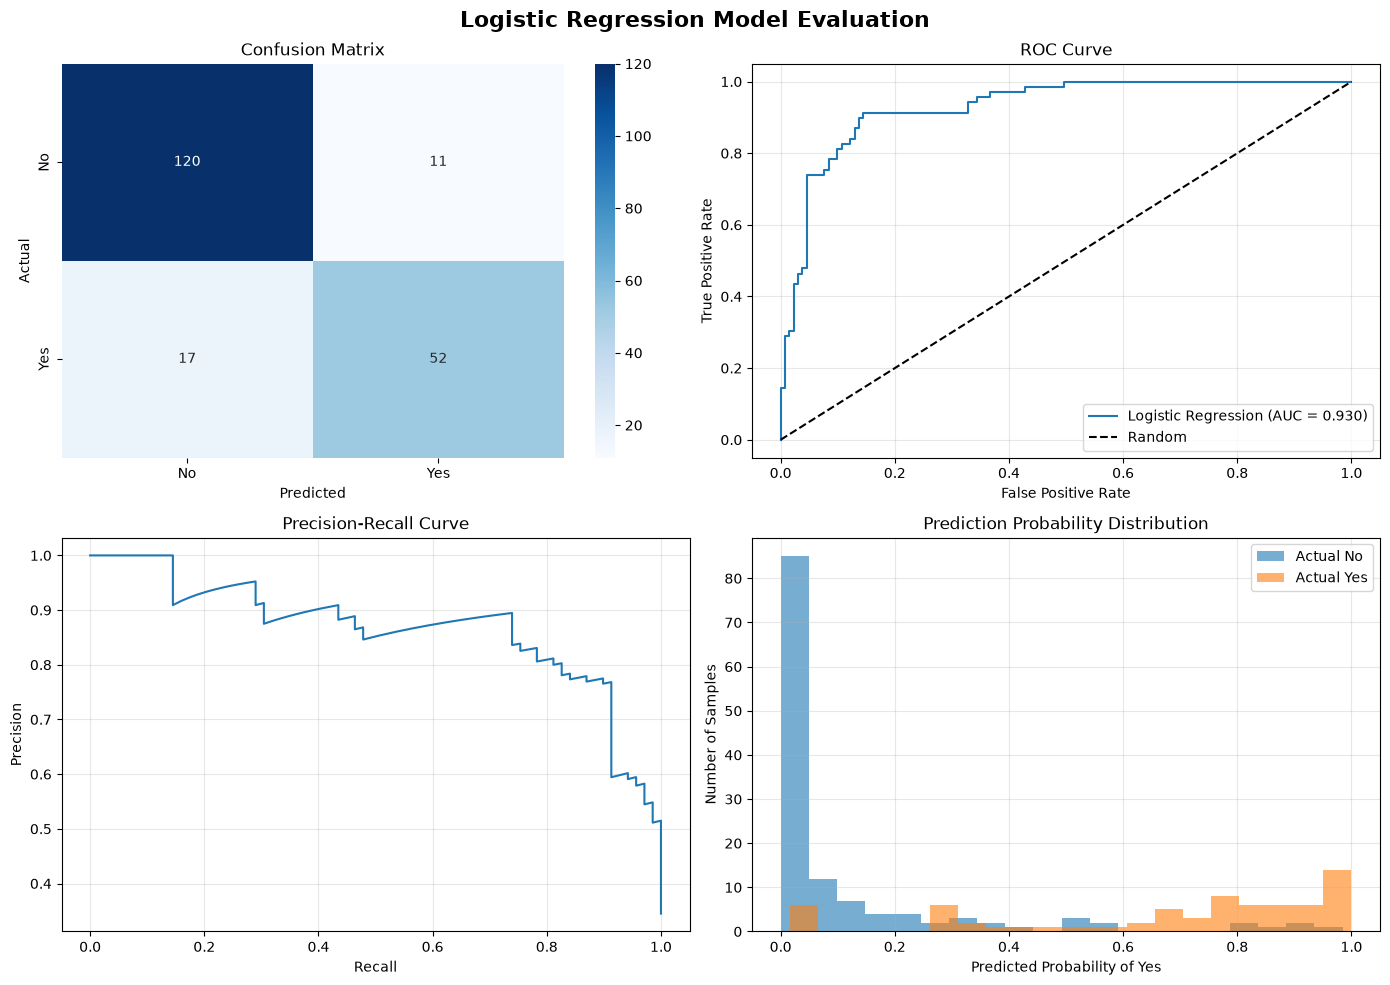

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

# Precision-Recall curve
precision_values, recall_values, pr_thresholds = (
    precision_recall_curve(y_test, y_prob)
)



fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)


# 1. Confusion Matrix


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"],
    ax=axes[0, 0]
)

axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Actual")
axes[0, 0].set_title("Confusion Matrix")



# 2. ROC Curve


axes[0, 1].plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

axes[0, 1].plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random"
)

axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].set_title("ROC Curve")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)



# 3. Precision-Recall Curve


axes[1, 0].plot(
    recall_values,
    precision_values
)

axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].set_title("Precision-Recall Curve")
axes[1, 0].grid(alpha=0.3)


# 4. Probability Distribution

axes[1, 1].hist(
    y_prob[y_test == 0],
    bins=20,
    alpha=0.6,
    label="Actual No"
)

axes[1, 1].hist(
    y_prob[y_test == 1],
    bins=20,
    alpha=0.6,
    label="Actual Yes"
)

axes[1, 1].set_xlabel("Predicted Probability of Yes")
axes[1, 1].set_ylabel("Number of Samples")
axes[1, 1].set_title("Prediction Probability Distribution")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)


# Overall layout

plt.suptitle(
    "Logistic Regression Model Evaluation",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()